# Анализ результатов A/B-тестирования

- Автор: Самонов Иван Андреевич
- Дата: 27.05.2026

## Цели и задачи

**Цель:** оценить результаты А/В тестирования

**Задачи:**

1. Загрузить данные теста.
2. Проверить корректность его проведения.
3. Проанализировать полученные результаты.

## Описание данных

1. `ab_test_participants.csv` - таблица участников тестов

`user_id` — идентификатор пользователя;<br>
`group` — группа пользователя;<br>
`ab_test` — название теста;<br>
`device` — устройство, с которого происходила регистрация.

2. `ab_test_events.zip` - архив с одним csv-файлом, в котором собраны события 2020 года

`user_id` — идентификатор пользователя;<br>
`event_dt` — дата и время события;<br>
`event_name` — тип события;<br>
`details` — дополнительные данные о событии.

## 1. Загрузка данных и проверка целостности 


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

In [2]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

In [3]:
# Данные таблицы participants
participants.info()
participants.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


In [4]:
participants['ab_test'].value_counts()

interface_eu_test          10850
recommender_system_test     3675
Name: ab_test, dtype: int64

В таблицы представлены данные двух тестов: тест системы рекомендаций и тест нового интерфейса

In [5]:
print(f"Количество дубликатов: {participants.duplicated().sum()}")
print(f"Относительное выражение: {round(participants.duplicated().mean()*100, 2)}%")

Количество дубликатов: 0
Относительное выражение: 0.0%


In [6]:
print(f"Количество пропусков: \n{participants.isna().sum()}")

Количество пропусков: 
user_id    0
group      0
ab_test    0
device     0
dtype: int64


In [7]:
# Данные таблицы events
events.info()
events.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


In [8]:
print(f"Количество дубликатов: {events.duplicated().sum()}")
print(f"Относительное выражение: {round(events.duplicated().mean()*100, 2)}%")

Количество дубликатов: 36318
Относительное выражение: 4.61%


In [9]:
# Удаление дубликатов
events = events.drop_duplicates().reset_index(drop=True)

In [10]:
print(f"Количество пропусков: \n{events.isna().sum()}")

Количество пропусков: 
user_id            0
event_dt           0
event_name         0
details       506063
dtype: int64


Пропуски в столбце `details` допустимы, поэтому оставим их без изменений

## 2. Оценка корректности проведения теста по таблице `ab_test_participants`:

In [11]:
# Запишем данные о тесте интерфейся в отдельную переменную
participants_test = participants[participants['ab_test'] == 'interface_eu_test']

#### Сравнение размера выборок

Text(0, 0.5, 'Количество')

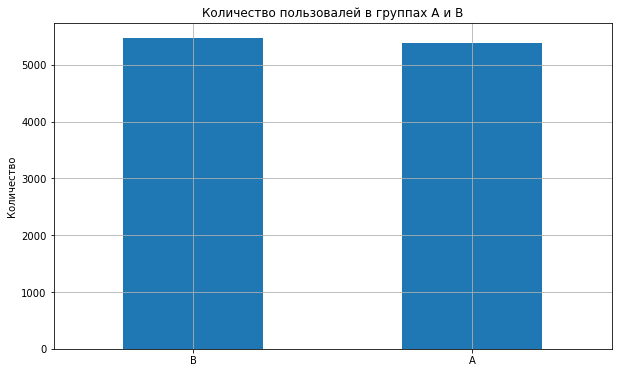

In [12]:
user_dist_ab = participants_test['group'].value_counts()
user_dist_ab.plot(
    kind='bar',
    figsize=(10, 6),
    grid=True,
    rot=0)
plt.title('Количество пользовалей в группах А и В')
plt.ylabel('Количество')

In [13]:
diff_ratio = abs(user_dist_ab.loc['A'] - user_dist_ab.loc['B']) / user_dist_ab.loc['A']
f"Размер групп различается на {round(diff_ratio*100, 2)}%"

'Размер групп различается на 1.56%'

#### Проверка пересечений

In [14]:
# Проверка групп на пересечение
list(set(participants_test[participants_test['group'] == 'A']['user_id']) & set(participants_test[participants_test['group'] == 'B']['user_id']))

[]

In [15]:
# Проверка пересечений по тестам
participants_B = participants[participants['group'] == 'B']
both_test_user_id = list(set(participants_B[participants_B['ab_test'] == 'interface_eu_test']['user_id']) & set(participants_B[participants_B['ab_test'] == 'recommender_system_test']['user_id']))
f"Число пользователей попавших в группу В в обоих тестах: {len(both_test_user_id)}"

'Число пользователей попавших в группу В в обоих тестах: 116'

In [16]:
# Удаление пользователей, попавших в оба теста
participants_test = participants_test[~participants_test['user_id'].isin(both_test_user_id)]

## 3. Анализ данных пользовательской активности по таблице `ab_test_events`

- оставим только события, связанные с участвующими в изучаемом тесте пользователями

In [17]:
events_test = events[events['user_id'].isin(participants_test['user_id'])]

- определеляем горизонт анализа: рассчитаем время совершения события пользователем после регистрации и оставим только те события, которые были выполнены в течение первых семи дней с момента регистрации

In [18]:
# Отбор нужных user_id
user_reg_dt = events_test[events_test['event_name'] == 'registration'][['user_id', 'event_dt']]
user_reg_dt.columns = ['user_id', 'reg_dt']

events_test_with_reg = events_test.merge(user_reg_dt, how='left', on='user_id')
events_test_with_reg['day_since_reg'] = (events_test_with_reg['event_dt'] - events_test_with_reg['reg_dt']).dt.days
user_id_test = events_test_with_reg[events_test_with_reg['day_since_reg'] < 7][['user_id', 'event_dt', 'event_name', 'details']]

In [19]:
events_test = user_id_test

Оценим достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

In [20]:
effect_size = proportion_effectsize(0.30, 0.33)
n = NormalIndPower().solve_power(effect_size, power=0.8, alpha=0.05)
print(f"Нужно наблюдений на группу: {int(n)}")

Нужно наблюдений на группу: 3761


- рассчитаем для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [21]:
events_test = events_test.merge(participants_test[['user_id', 'group']], how='left', on='user_id')

In [22]:
# Группа А
purch_users_A = events_test[(events_test['event_name'] == 'purchase') & (events_test['group'] == 'A')]['user_id'].nunique()
total_users_A = events_test[events_test['group'] == 'A']['user_id'].nunique()
conv_rate_A = round((purch_users_A / total_users_A)*100, 2)

print('Группа А:')
print(f"Количество пользователей сделавших покупку: {purch_users_A}")
print(f"Общее количество пользователей в группе: {total_users_A}")
print(f"Конверсия группы: {conv_rate_A}%")

Группа А:
Количество пользователей сделавших покупку: 1480
Общее количество пользователей в группе: 5383
Конверсия группы: 27.49%


In [23]:
# Группа B
purch_users_B = events_test[(events_test['event_name'] == 'purchase') & (events_test['group'] == 'B')]['user_id'].nunique()
total_users_B = events_test[events_test['group'] == 'B']['user_id'].nunique()
conv_rate_B = round((purch_users_B / total_users_B)*100, 2)

print('Группа B:')
print(f"Количество пользователей сделавших покупку: {purch_users_B}")
print(f"Общее количество пользователей в группе: {total_users_B}")
print(f"Конверсия группы: {conv_rate_B}%")

Группа B:
Количество пользователей сделавших покупку: 1579
Общее количество пользователей в группе: 5351
Конверсия группы: 29.51%


- **Предварительный общий вывод об изменении пользовательской активности в тестовой группе**

По ручному подсчету конверсии в группах А и В можно сказать следующее: конверсия в тестовой группе выросла чуть больше чем на 2 п.п., что не удовлетворяет желаемому результату (рост конверсии на 3 п.п.)

## 4. Оценка результатов A/B-тестирования:

- **Нулевая гипотеза H₀:** конверсия в группах А и В не различается
- **Альтернативная гипотеза H₁:** конверсия в группе В больше, и это различие статистически значимо

In [24]:
alpha = 0.05
stat_ztest, p_value_ztest = proportions_ztest(
    [purch_users_A, purch_users_B],
    [total_users_A, total_users_B],
    alternative='smaller'
)

print(f"p-value = {p_value_ztest}")

if p_value_ztest > alpha:
    print('Нулевая гипотеза находит подтверждение!')
else:
    print('Нулевая гипотеза не находит подтверждения!')

p-value = 0.010393282955333764
Нулевая гипотеза не находит подтверждения!


**Вывод по результатам теста**

Конверсия в группе В выросла примерно на 2.2 п.п. Для проверки был выбран Z-тест пропорций, который позволяет оценить значимость изменения конверсии (долевой метрики). Тест подтвердил значимость этого изменения. Однако ожидаемый эффект (изменение конверсии на 3 п.п.) достигнут не был.